In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from tqdm.notebook import tqdm as tqdm
from scipy.stats import norm
from scipy.integrate import trapezoid
from oetils import init_plotting

In [2]:
W = init_plotting(latex=True, sans=True)

---

# Exercise 5.2

In [3]:
xi = np.linspace(-4, 4, 1_000_000)
e = lambda x, s: trapezoid(np.round(x + xi[:, None]) * norm(0, s).pdf(xi)[:, None], xi, axis=0)
v = lambda es, x, s: trapezoid(norm(0, s).pdf(xi)[:, None] * (np.round(x + xi[:, None]) - es)**2, xi, axis=0)

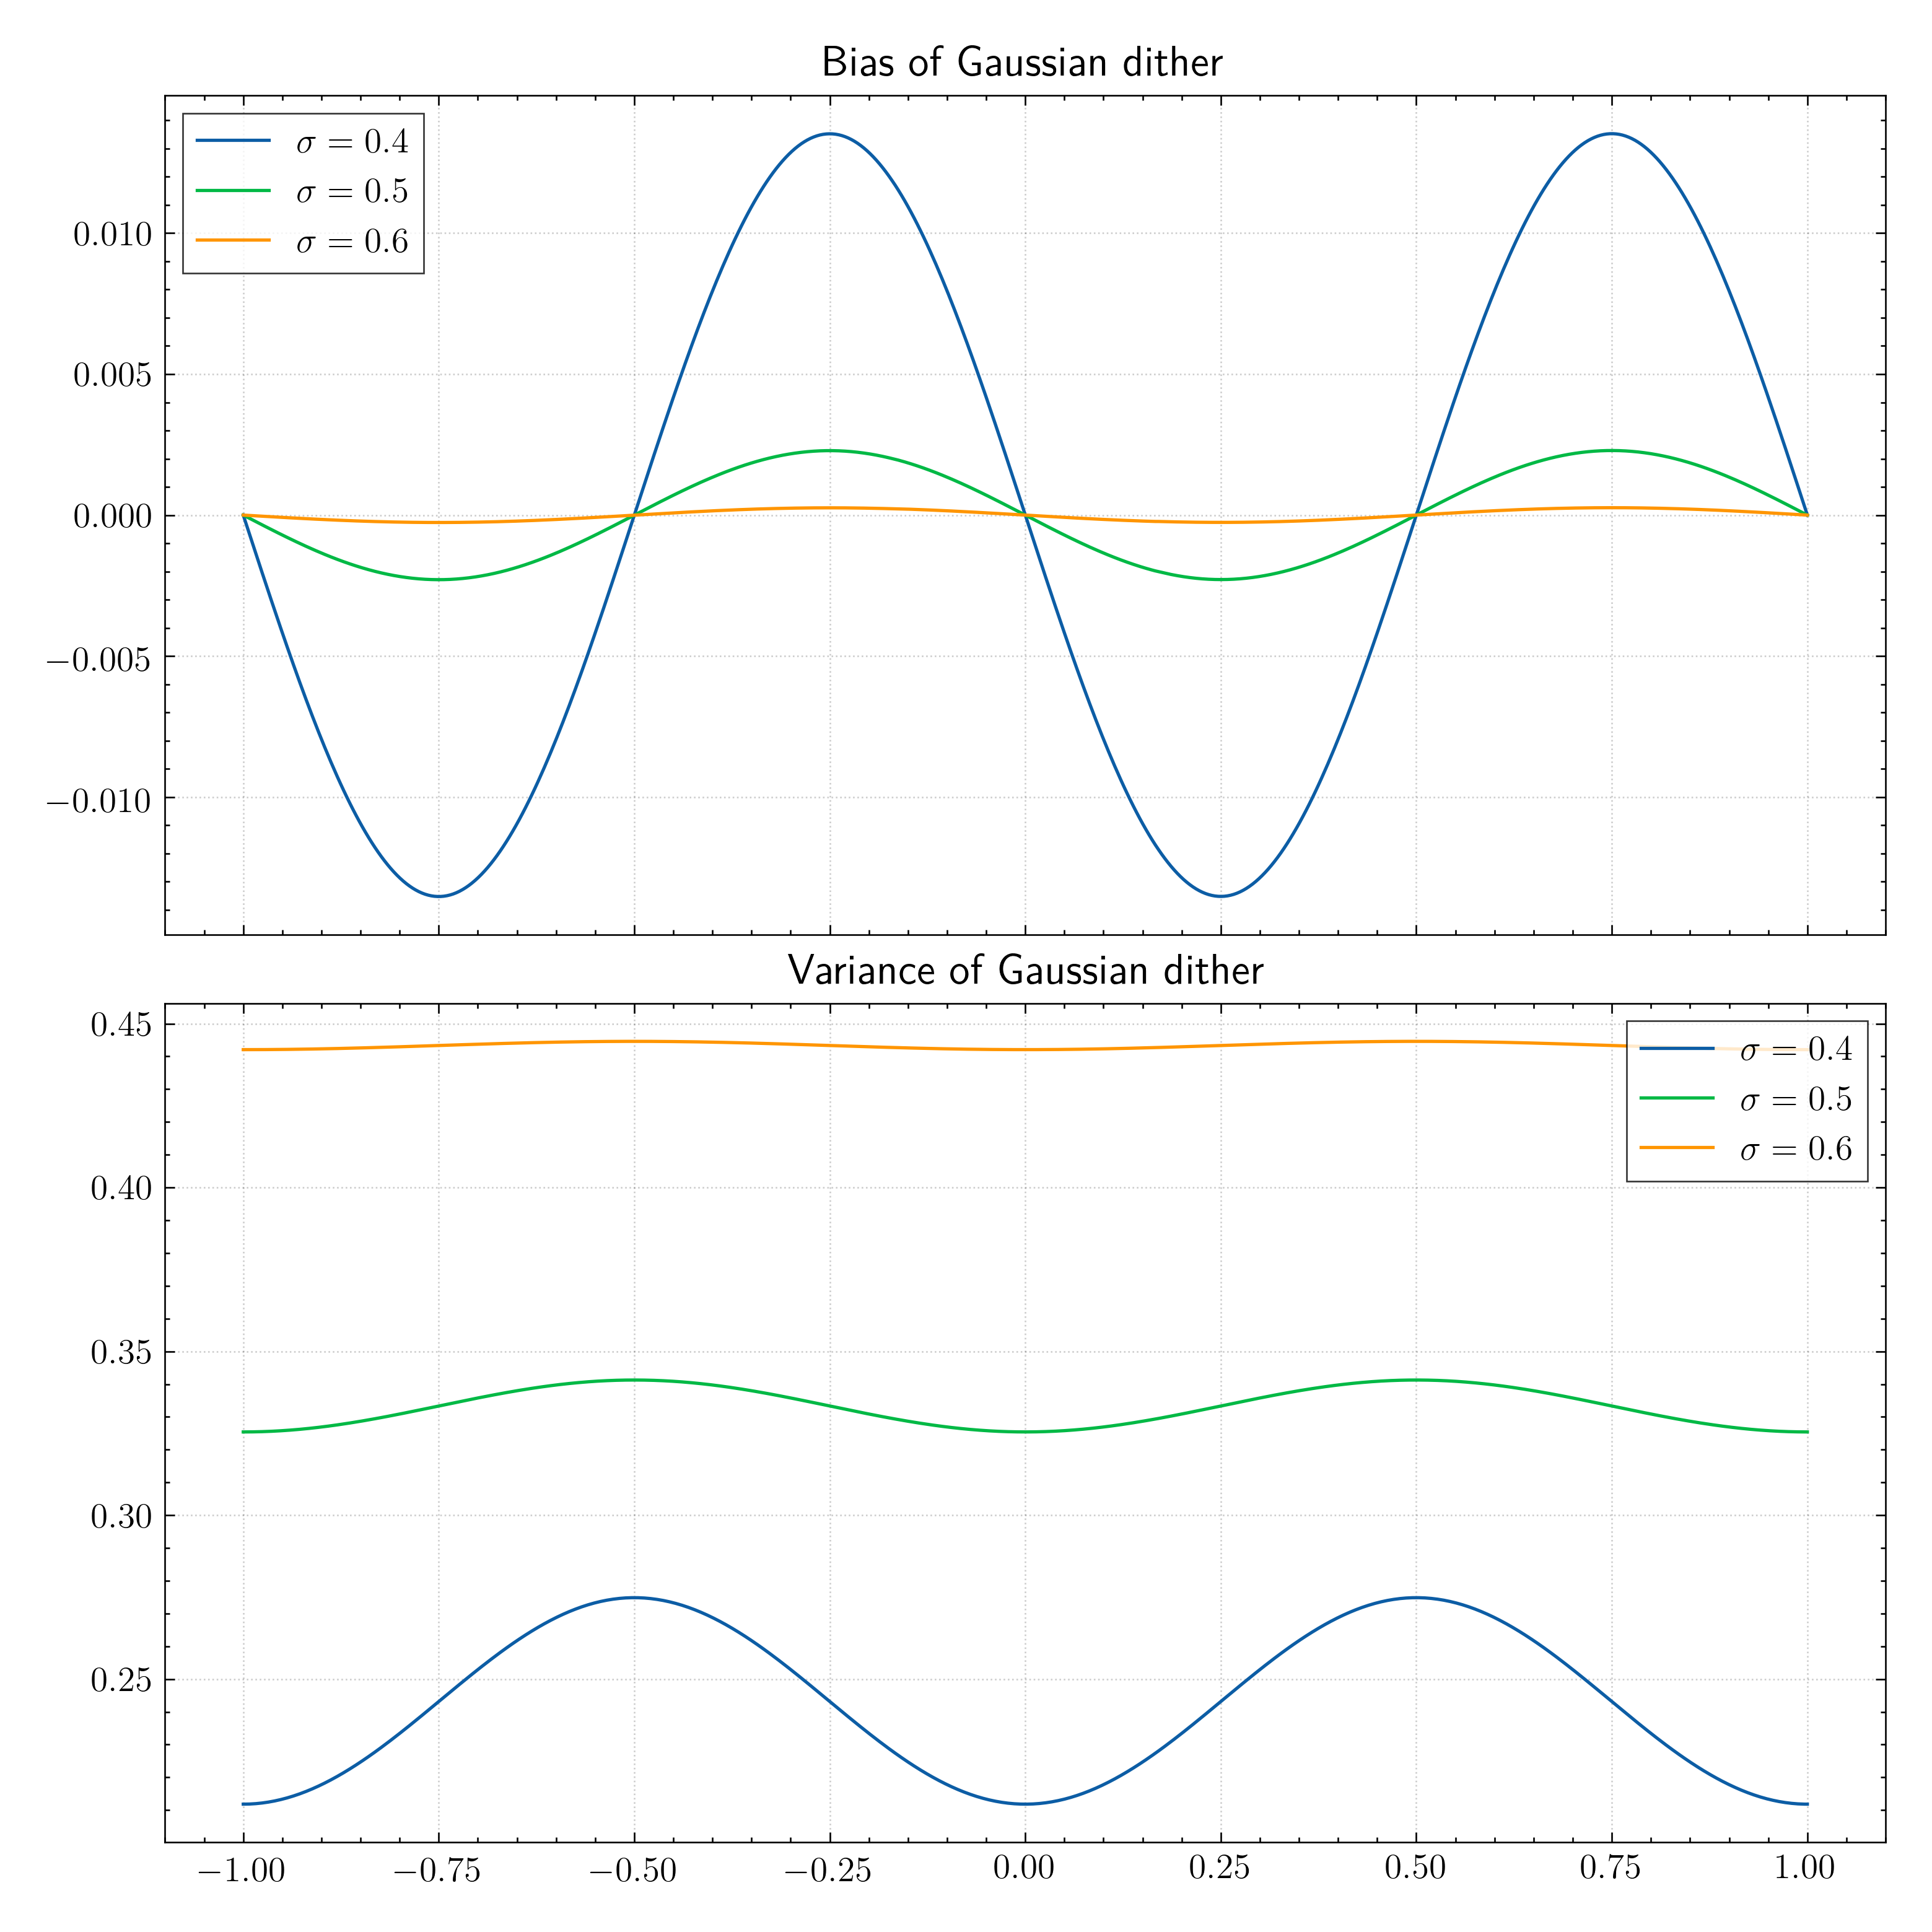

In [4]:
x = np.linspace(-1, 1, 500)
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(W, W))
ax[0].set_title('Bias of Gaussian dither')
ax[1].set_title('Variance of Gaussian dither')
for s in [0.4, 0.5, 0.6]:
    es = e(x, s)
    bs = es - x
    vs = v(es, x, s)
    ax[0].plot(x, bs, label=f'$\sigma = {s:.1f}$')
    ax[1].plot(x, vs, label=f'$\sigma = {s:.1f}$')
ax[0].legend()
ax[1].legend()
plt.show()